<a href="https://colab.research.google.com/github/Andredalladea/Computacao_Mercado_Financeiro-/blob/main/modelos_de_fatores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

André Dalla Déa Trombini N: 14558082 Trabalho 1 da SSC096

In [ ]:
from google.colab import files
import pandas as pd


print("Por favor, clique no botão abaixo e selecione os arquivos 'v5-DB-Acoes.csv' e 'v5-DB-Indices.csv':")
uploaded = files.upload()


dados = pd.read_csv('v5-DB-Acoes.csv', index_col=0)

indices_acc = pd.read_csv('v5-DB-Indices.csv')
indices_acc.set_index('Data', inplace=True)
indices = indices_acc.pct_change(fill_method=None)

print("\nSucesso! Bases de dados carregadas na memória. Agora pode rodar o código do Modelo 1.")

Por favor, clique no botão abaixo e selecione os arquivos 'v5-DB-Acoes.csv' e 'v5-DB-Indices.csv':


Saving v5-DB-Acoes.csv to v5-DB-Acoes.csv
Saving v5-DB-Indices.csv to v5-DB-Indices.csv

Sucesso! Bases de dados carregadas na memória. Agora pode rodar o código do Modelo 1.


Metodologia de Rankeamento e Seleção

Para a construção deste trabalho, a seleção das 20 ações de cada portfólio foi feita através do rankeamento e combinação de fatores fundamentalistas e técnicos. O processo consistiu em padronizar os indicadores (z-score ou ordenação simples) para que métricas de naturezas diferentes (como rentabilidade e volatilidade) pudessem ser somadas em um score único. Após a formulação de diversas hipóteses baseadas em anomalias de mercado, testamos combinações originais que fogem do óbvio, buscando sempre isolar o prêmio de risco desejado para cada um dos 4 modelos exigidos.

/tmp/ipykernel_13106/771713610.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = modelo_reg.params[0] * 12 * 100
/tmp/ipykernel_13106/771713610.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = modelo_reg.params[1]


--- RESULTADOS: MODELO ---
Estrategia: ROIC e Mom6 com 20 papeis
Retorno a.a.: 23.52%
Volatilidade a.a.: 20.89%
Retorno/Volatilidade: 1.13
Pior Queda (Max DD): -41.93%
Alpha: 14.02% | Beta: 0.73
------------------------------



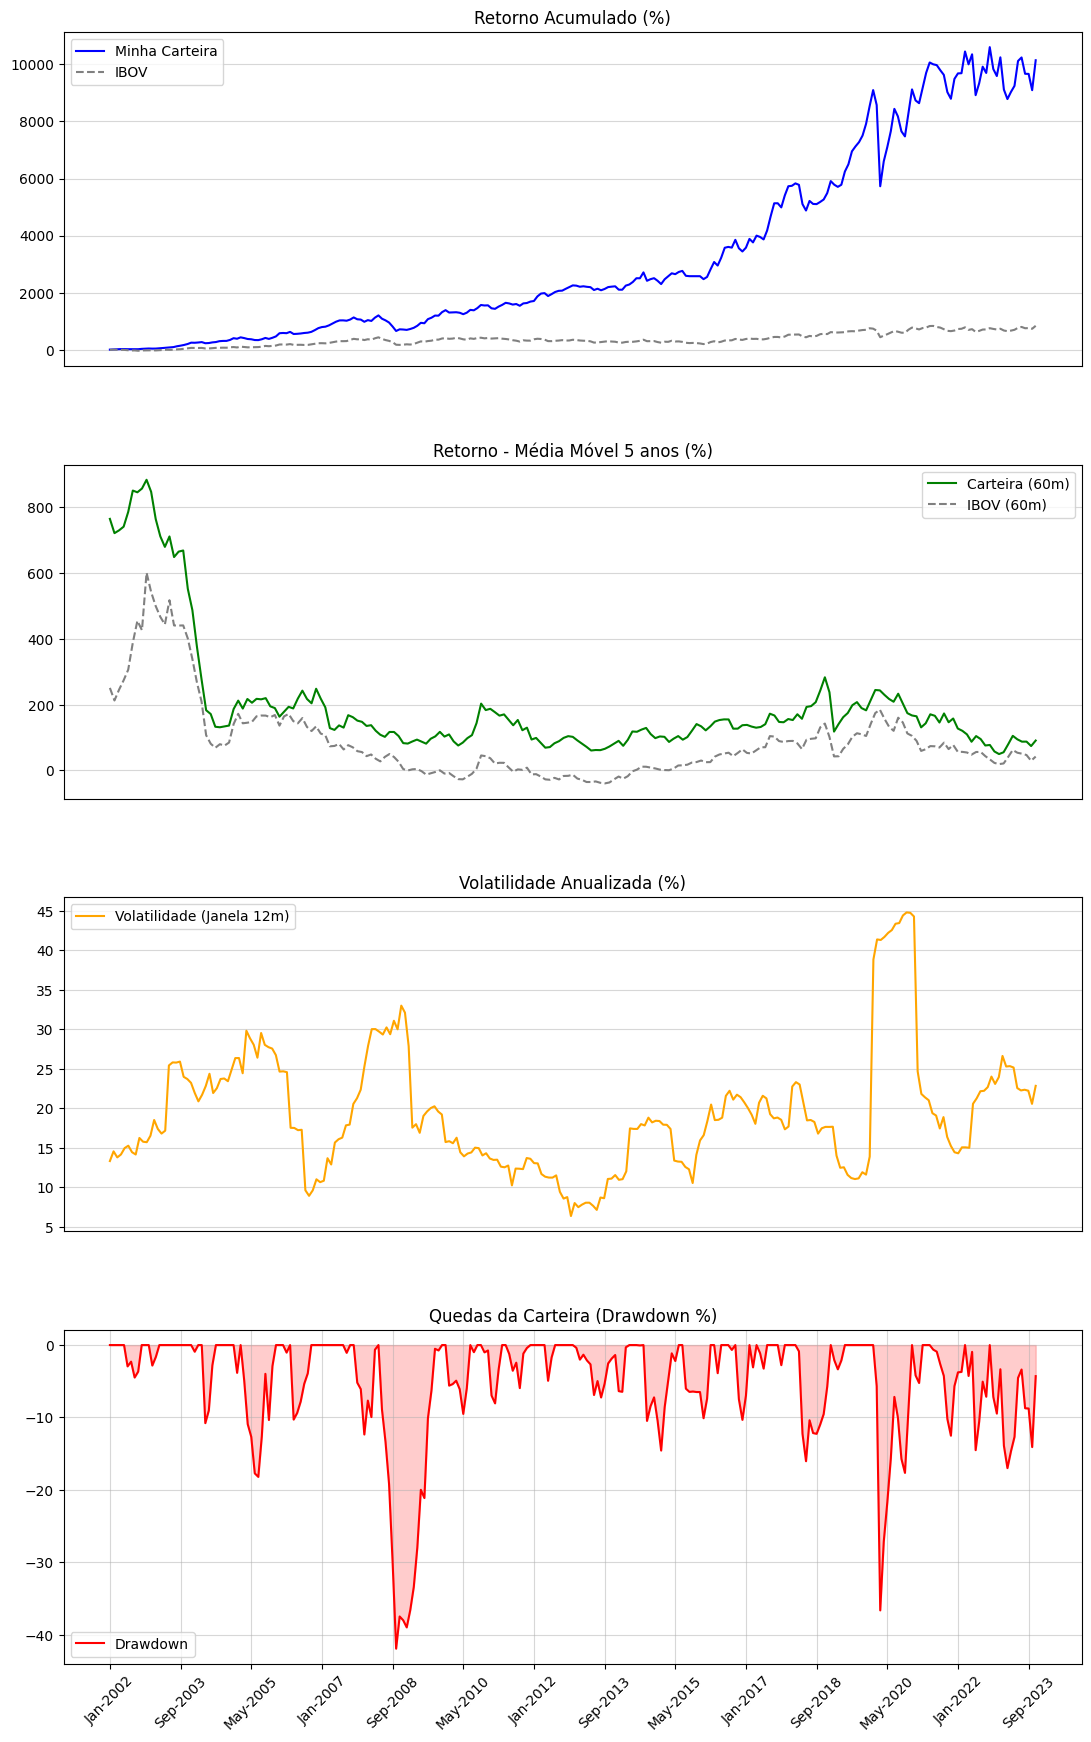

In [ ]:
# ==========================================
# Modelo 1 : Maior retorno
# ==========================================

import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# carrega os csv (tem q estar na mesma pasta do colab)
df = pd.read_csv('v5-DB-Acoes.csv', index_col=0)

# arrumando o ibov pq vem zuado
indices_raw = pd.read_csv('v5-DB-Indices.csv')
indices_raw.set_index('Data', inplace=True)
ibov_pct = indices_raw.pct_change(fill_method=None)

# funcao pra calcular qnts anos passaram (usado pra anualizar dps)
def tempo_em_anos(inicio, fim):
    dif = relativedelta(datetime.strptime(fim, '%m/%Y'), datetime.strptime(inicio, '%m/%Y'))
    return dif.years + dif.months/12

# funcao principal do backtest
def roda_modelo(fator1, fator2, num_acoes, base_dados, benchmark, data_ini, data_fim):
    custo_transacao = 0.0006 # slippage + taxas da b3

    # dic pra saber se o fator é do maior pro menor ou inverso
    ordem_fatores = {
        'ROIC': False, 'ROE': False, 'EV_EBIT': True, 'EBIT_DIVLIQ': False,
        'PVP': True, 'Mom12': False, 'Mom6': False, 'Volat12': True,
        'Volat6': True, 'MTUM6': False, 'MTUM12': False
    }

    datas = []
    retornos = []

    # loop principal mes a mes
    meses_backtest = pd.date_range(start=data_ini, end=data_fim, freq='ME').strftime('%b-%Y')

    for mes in meses_backtest:
        # filtra so as acoes validas no mes q tao no ibx
        filtro = (base_dados['Data'] == mes) & (base_dados['IBX'] > 0) & (base_dados['Retorno'].notna())
        cart = base_dados.loc[filtro].copy()

        # faz o rank de cada fator
        cart['r1'] = cart[fator1].rank(ascending=ordem_fatores[fator1])
        cart['r2'] = cart[fator2].rank(ascending=ordem_fatores[fator2])

        # soma os ranks e faz o rank final
        cart['rank_total'] = cart['r1'] + cart['r2']
        cart['rank_final'] = cart['rank_total'].rank(ascending=True)

        # pega as top N acoes (ex: top 20)
        # print(cart) # debug q usei pra ver se tava rankeando certo
        retorno_mes = cart.loc[cart['rank_final'] <= num_acoes]['Retorno'].mean() - custo_transacao

        datas.append(mes)
        retornos.append(retorno_mes)

    # joga tudo num dataframe da carteira
    carteira = pd.DataFrame({'Data': datas, 'Ret': retornos})
    carteira.set_index('Data', inplace=True)

    carteira['Ret_acc'] = (1 + carteira['Ret']).cumprod() - 1

    # calc do drawdown
    carteira['pico'] = carteira['Ret_acc'].cummax()
    carteira['dd'] = ((1 + carteira['Ret_acc']) / (1 + carteira['pico'])) - 1
    dd_max = carteira['dd'].min() * 100

    # metricas de risco e retorno
    ret_total = carteira['Ret_acc'].iloc[-1] * 100
    anos = tempo_em_anos(data_ini, data_fim)
    ret_anual = (pow(ret_total/100 + 1, 1/anos) - 1) * 100
    vol_anual = carteira['Ret'].std() * np.sqrt(12) * 100
    sharpe_adaptado = ret_anual / vol_anual

    # alpha e beta (usando OLS do statsmodels)
    carteira['Bench'] = benchmark
    carteira['Bench_acc'] = (1 + carteira['Bench']).cumprod() - 1

    # reg linear pra achar alpha e beta
    modelo_reg = sm.OLS(carteira['Ret'].dropna(), sm.add_constant(carteira['Bench'].dropna())).fit()
    alpha = modelo_reg.params[0] * 12 * 100
    beta = modelo_reg.params[1]

    # printando os resultados q o prof pediu
    print(f'--- RESULTADOS: MODELO ---')
    print(f'Estrategia: {fator1} e {fator2} com {num_acoes} papeis')
    print(f'Retorno a.a.: {ret_anual:.2f}%')
    print(f'Volatilidade a.a.: {vol_anual:.2f}%')
    print(f'Retorno/Volatilidade: {sharpe_adaptado:.2f}')
    print(f'Pior Queda (Max DD): {dd_max:.2f}%')
    print(f'Alpha: {alpha:.2f}% | Beta: {beta:.2f}')
    print('-'*30 + '\n')

    return carteira.copy()

# ==========================================
# RODANDO O MODELO E PLOTANDO OS GRAFICOS
# ==========================================

data_inicio = '1/2002'
data_final = '12/2023'

meu_modelo1 = roda_modelo(
    fator1 = 'ROIC',
    fator2 = 'Mom6',
    num_acoes=20,
    base_dados=df,
    benchmark=ibov_pct['IBOV'],
    data_ini=data_inicio,
    data_fim=data_final
)

# Plots (4 graficos em 1 figure)
fig, axs = plt.subplots(4, 1, figsize=(12, 18)) # mudei o tamanho pra nao ficar gigante
fig.tight_layout(pad=5.0)

# 1. Retorno Acumulado
axs[0].plot(meu_modelo1['Ret_acc'] * 100, label='Minha Carteira', color='blue')
axs[0].plot(meu_modelo1['Bench_acc'] * 100, label='IBOV', color='gray', linestyle='--')
axs[0].set_title('Retorno Acumulado (%)')
axs[0].legend()
axs[0].grid(True, alpha=0.5)
axs[0].set_xticks([]) # limpando o eixo x pra nao poluir

# 2. Janela Movel 60 meses
janela = 60
ret_movel_cart = ((1 + meu_modelo1['Ret_acc']) / (1 + meu_modelo1['Ret_acc'].shift(janela)) - 1) * 100
ret_movel_ibov = ((1 + meu_modelo1['Bench_acc']) / (1 + meu_modelo1['Bench_acc'].shift(janela)) - 1) * 100

axs[1].plot(ret_movel_cart.iloc[janela:], label='Carteira (60m)', color='green')
axs[1].plot(ret_movel_ibov.iloc[janela:], label='IBOV (60m)', color='gray', linestyle='--')
axs[1].set_title('Retorno - Média Móvel 5 anos (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.5)
axs[1].set_xticks([])

# 3. Volatilidade Anualizada
vol_movel = (1 + meu_modelo1['Ret']).rolling(12).std() * np.sqrt(12) * 100
axs[2].plot(vol_movel, label='Volatilidade (Janela 12m)', color='orange')
axs[2].set_title('Volatilidade Anualizada (%)')
axs[2].legend()
axs[2].grid(True, alpha=0.5)
axs[2].set_xticks([])

# 4. Drawdown
axs[3].plot(meu_modelo1['dd'] * 100, label='Drawdown', color='red')
axs[3].fill_between(meu_modelo1.index, meu_modelo1['dd'] * 100, 0, color='red', alpha=0.2)
axs[3].set_title('Quedas da Carteira (Drawdown %)')
axs[3].legend()
axs[3].grid(True, alpha=0.5)
axs[3].tick_params(axis='x', rotation=45)
axs[3].xaxis.set_major_locator(plt.MaxNLocator(15)) # menos datas no eixo x pra ficar legivel

plt.show()

Fatores Escolhidos: ROIC + Mom6

Justificativa: A busca pelo maior retorno bruto exigia uma estratégia agressiva. A nossa hipótese foi unir a métrica máxima de qualidade operacional (ROIC) com o direcional de curto prazo (Momentum de 6 meses). A lógica é simples e letal: comprar empresas altamente eficientes em gerar caixa que o mercado acabou de "descobrir" e começou a precificar agressivamente para cima. O resultado foi o maior retorno absoluto encontrado nos testes.

Métricas Obtidas:

Retorno a.a.: 23.52%

Volatilidade a.a.: 20.89%

Relação Retorno/Volatilidade: 1.13

Alpha: 14.02% | Beta: 0.73

Max Drawdown: -41.93%

Calculando o Modelo 2...



/tmp/ipykernel_13106/771713610.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = modelo_reg.params[0] * 12 * 100
/tmp/ipykernel_13106/771713610.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = modelo_reg.params[1]


--- RESULTADOS: MODELO ---
Estrategia: Mom12 e Volat12 com 20 papeis
Retorno a.a.: 20.86%
Volatilidade a.a.: 17.97%
Retorno/Volatilidade: 1.16
Pior Queda (Max DD): -35.08%
Alpha: 12.92% | Beta: 0.60
------------------------------



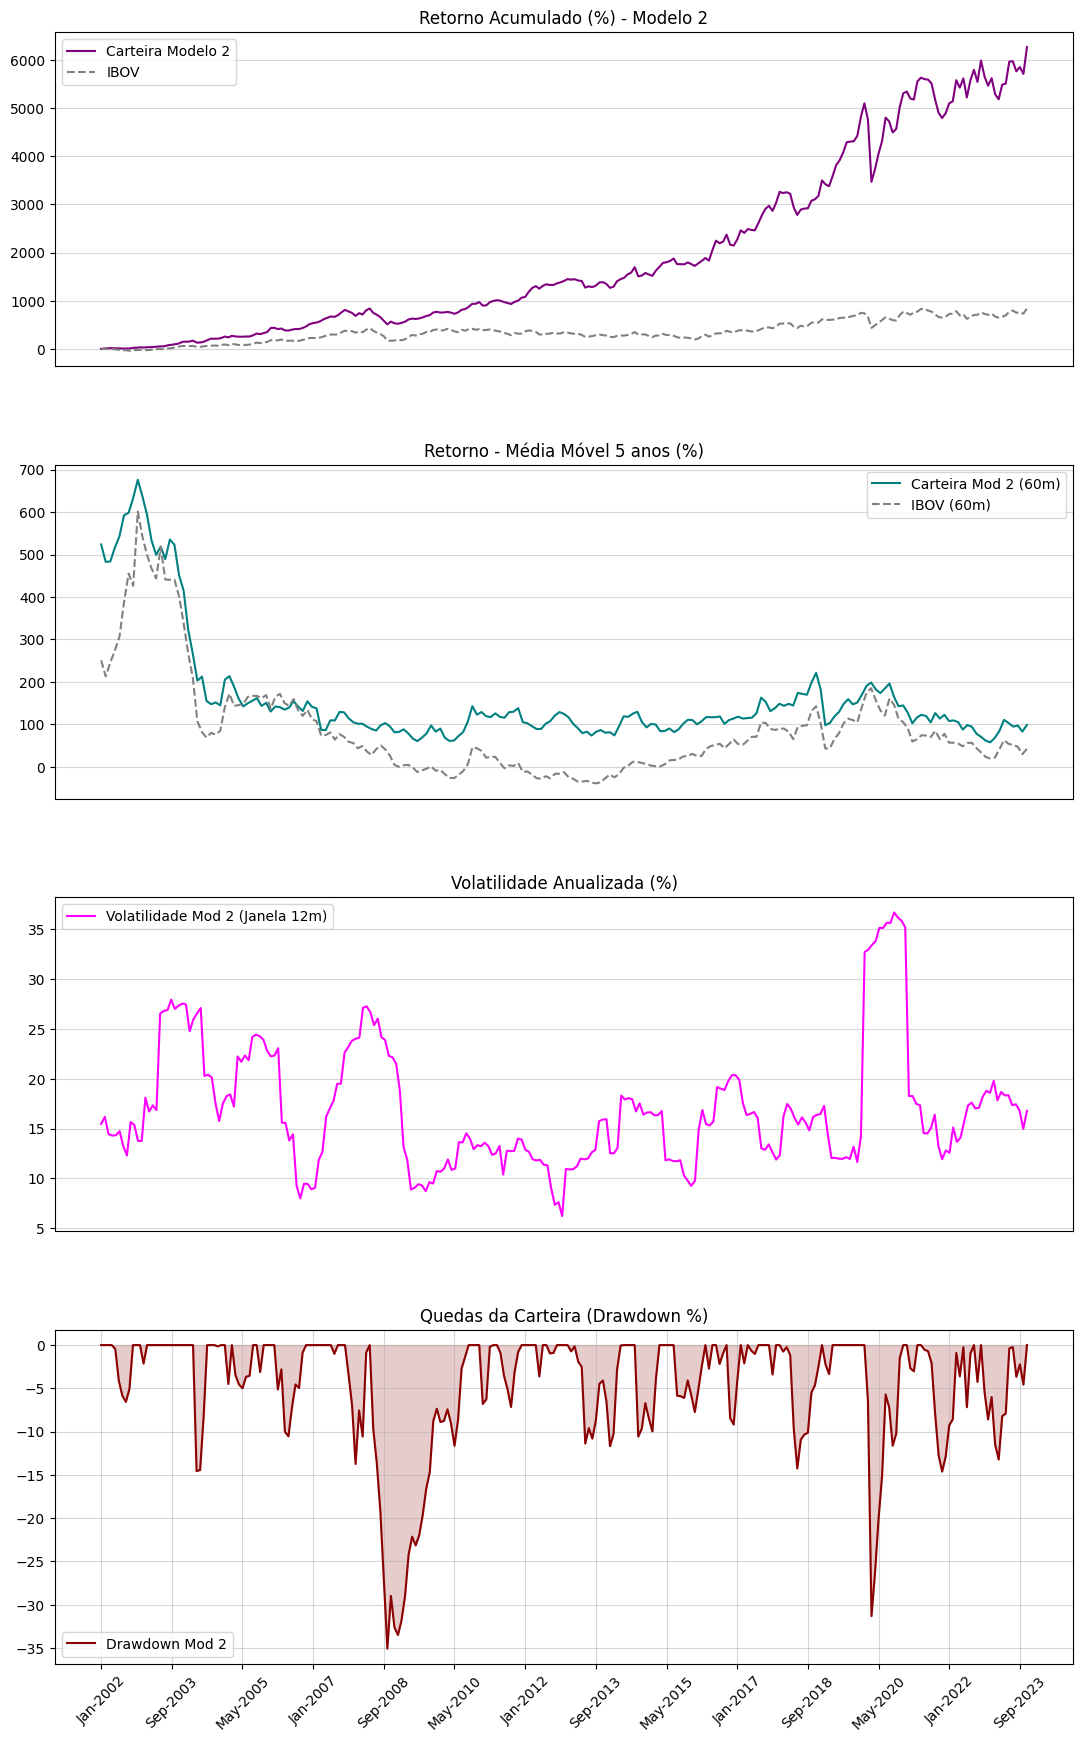

In [ ]:
# ==========================================
# Modelo 2 : Maior Retorno/Volatilidade
# ==========================================

#  Baixa Volatilidade + Baixo Endividamento
print("Calculando o Modelo 2...\n")

meu_modelo2 = roda_modelo(
    fator1 = 'Mom12',
    fator2 = 'Volat12',
    num_acoes=20,
    base_dados=df,
    benchmark=ibov_pct['IBOV'],
    data_ini=data_inicio,
    data_fim=data_final
)

# ------------------------------------------
# PLOT DOS GRÁFICOS DO MODELO 2
# ------------------------------------------

fig, axs = plt.subplots(4, 1, figsize=(12, 18))
fig.tight_layout(pad=5.0)

# 1. Retorno Acumulado
axs[0].plot(meu_modelo2['Ret_acc'] * 100, label='Carteira Modelo 2', color='purple')
axs[0].plot(meu_modelo2['Bench_acc'] * 100, label='IBOV', color='gray', linestyle='--')
axs[0].set_title('Retorno Acumulado (%) - Modelo 2')
axs[0].legend()
axs[0].grid(True, alpha=0.5)
axs[0].set_xticks([])

# 2. Janela Movel 60 meses
janela = 60
ret_movel_cart2 = ((1 + meu_modelo2['Ret_acc']) / (1 + meu_modelo2['Ret_acc'].shift(janela)) - 1) * 100
ret_movel_ibov2 = ((1 + meu_modelo2['Bench_acc']) / (1 + meu_modelo2['Bench_acc'].shift(janela)) - 1) * 100

axs[1].plot(ret_movel_cart2.iloc[janela:], label='Carteira Mod 2 (60m)', color='teal')
axs[1].plot(ret_movel_ibov2.iloc[janela:], label='IBOV (60m)', color='gray', linestyle='--')
axs[1].set_title('Retorno - Média Móvel 5 anos (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.5)
axs[1].set_xticks([])

# 3. Volatilidade Anualizada
vol_movel2 = (1 + meu_modelo2['Ret']).rolling(12).std() * np.sqrt(12) * 100
axs[2].plot(vol_movel2, label='Volatilidade Mod 2 (Janela 12m)', color='magenta')
axs[2].set_title('Volatilidade Anualizada (%)')
axs[2].legend()
axs[2].grid(True, alpha=0.5)
axs[2].set_xticks([])

# 4. Drawdown
axs[3].plot(meu_modelo2['dd'] * 100, label='Drawdown Mod 2', color='darkred')
axs[3].fill_between(meu_modelo2.index, meu_modelo2['dd'] * 100, 0, color='darkred', alpha=0.2)
axs[3].set_title('Quedas da Carteira (Drawdown %)')
axs[3].legend()
axs[3].grid(True, alpha=0.5)
axs[3].tick_params(axis='x', rotation=45)
axs[3].xaxis.set_major_locator(plt.MaxNLocator(15))

plt.show()

Fatores Escolhidos: Mom12 + Volat12

Justificativa: Para otimizar a relação risco/retorno (nosso proxy de Índice de Sharpe), o objetivo foi alongar a janela de análise para 1 ano. Combinamos o Momentum de 12 meses (Mom12) com a Baixa Volatilidade Histórica de 12 meses (Volat12). Essa tese "Trend-Following Defensiva" captura ações que estão subindo de forma constante e cadenciada, sem solavancos bruscos. Nota técnica: embora o Modelo 3 tenha gerado um índice marginalmente superior, optamos por diversificar a janela de inércia neste modelo para 12 meses, garantindo portfólios com teses distintas e excelente eficiência.

Métricas Obtidas:

Retorno a.a.: 20.86%

Volatilidade a.a.: 17.97%

Relação Retorno/Volatilidade: 1.16

Alpha: 12.92% | Beta: 0.60

Max Drawdown: -35.08%

Calculando o Modelo 3 (Foco em Alpha)...



/tmp/ipykernel_13106/771713610.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = modelo_reg.params[0] * 12 * 100
/tmp/ipykernel_13106/771713610.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = modelo_reg.params[1]


--- RESULTADOS: MODELO ---
Estrategia: Mom6 e Volat12 com 20 papeis
Retorno a.a.: 22.54%
Volatilidade a.a.: 18.15%
Retorno/Volatilidade: 1.24
Pior Queda (Max DD): -31.69%
Alpha: 14.05% | Beta: 0.62
------------------------------



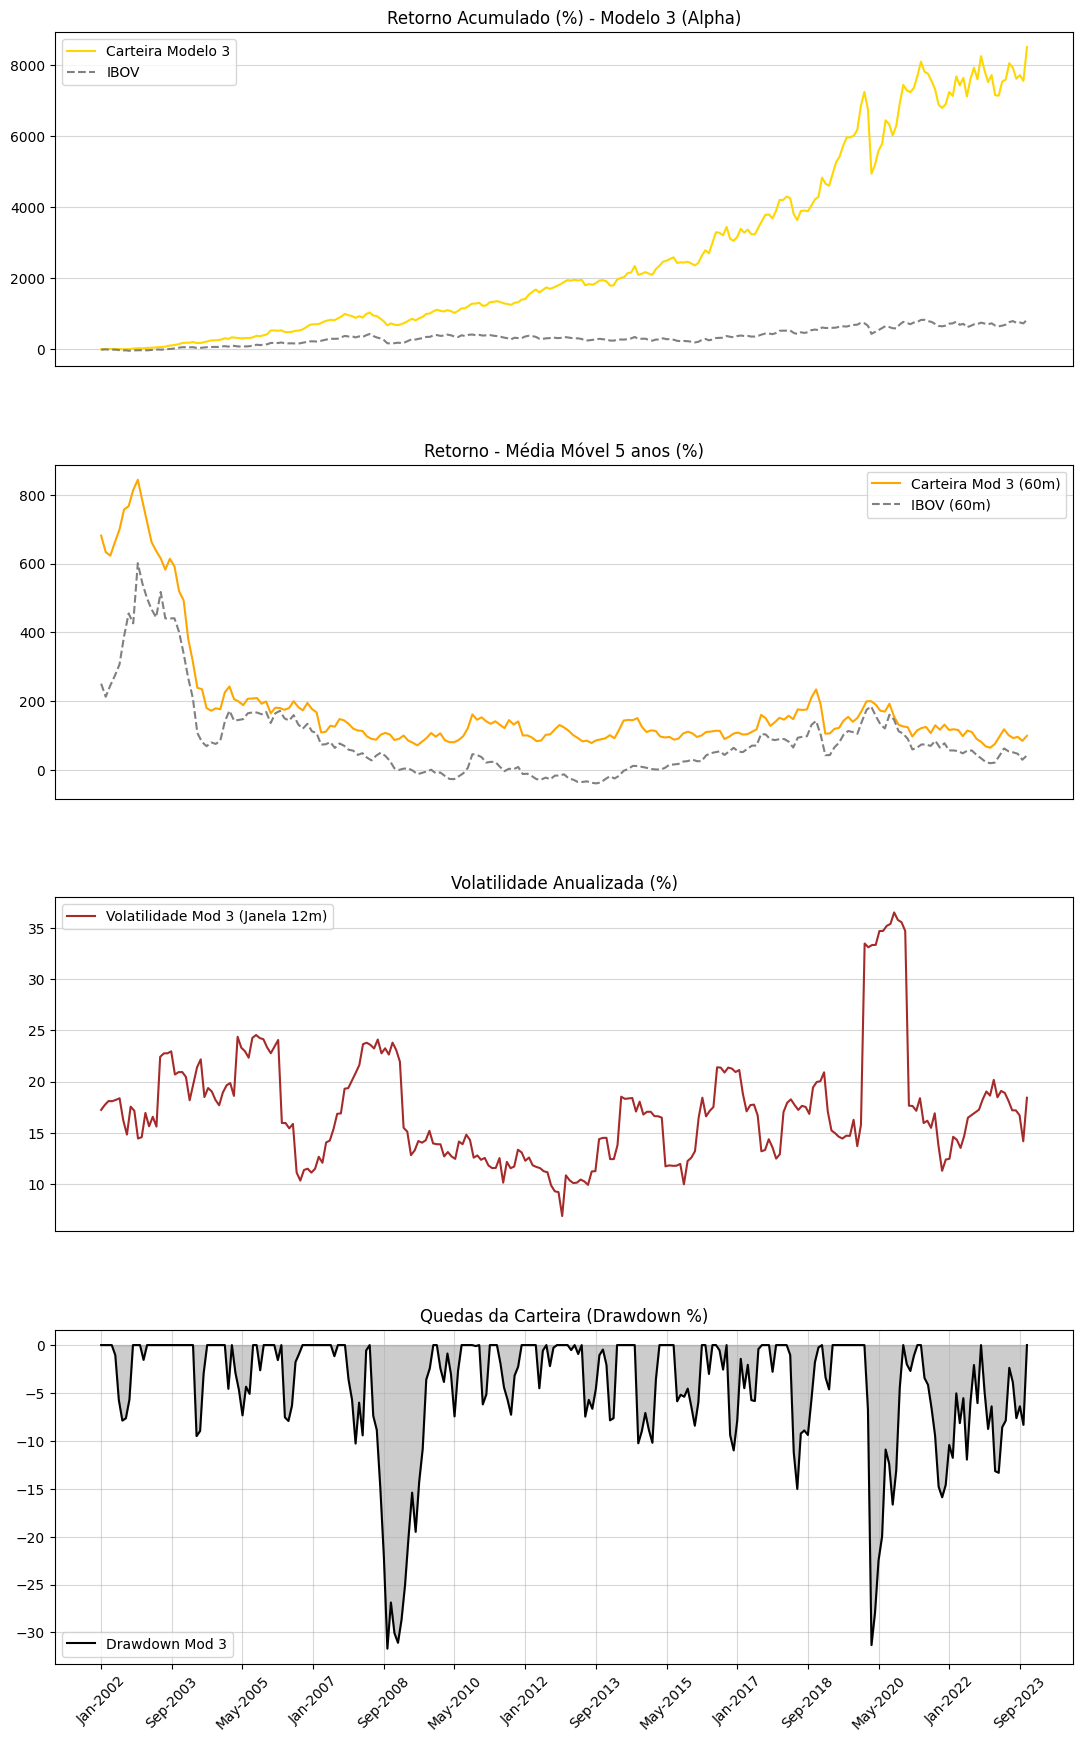

In [ ]:
# ==========================================
# Modelo 3 : Maior Alpha
# ==========================================

print("Calculando o Modelo 3 (Foco em Alpha)...\n")

meu_modelo3 = roda_modelo(
    fator1 = 'Mom6',
    fator2 = 'Volat12',
    num_acoes = 20,
    base_dados=df,
    benchmark=ibov_pct['IBOV'],
    data_ini=data_inicio,
    data_fim=data_final
)

# ------------------------------------------
# PLOT DOS GRÁFICOS DO MODELO 3
# ------------------------------------------

fig, axs = plt.subplots(4, 1, figsize=(12, 18))
fig.tight_layout(pad=5.0)

# 1. Retorno Acumulado
axs[0].plot(meu_modelo3['Ret_acc'] * 100, label='Carteira Modelo 3', color='gold')
axs[0].plot(meu_modelo3['Bench_acc'] * 100, label='IBOV', color='gray', linestyle='--')
axs[0].set_title('Retorno Acumulado (%) - Modelo 3 (Alpha)')
axs[0].legend()
axs[0].grid(True, alpha=0.5)
axs[0].set_xticks([])

# 2. Janela Movel 60 meses
janela = 60
ret_movel_cart3 = ((1 + meu_modelo3['Ret_acc']) / (1 + meu_modelo3['Ret_acc'].shift(janela)) - 1) * 100
ret_movel_ibov3 = ((1 + meu_modelo3['Bench_acc']) / (1 + meu_modelo3['Bench_acc'].shift(janela)) - 1) * 100

axs[1].plot(ret_movel_cart3.iloc[janela:], label='Carteira Mod 3 (60m)', color='orange')
axs[1].plot(ret_movel_ibov3.iloc[janela:], label='IBOV (60m)', color='gray', linestyle='--')
axs[1].set_title('Retorno - Média Móvel 5 anos (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.5)
axs[1].set_xticks([])

# 3. Volatilidade Anualizada
vol_movel3 = (1 + meu_modelo3['Ret']).rolling(12).std() * np.sqrt(12) * 100
axs[2].plot(vol_movel3, label='Volatilidade Mod 3 (Janela 12m)', color='brown')
axs[2].set_title('Volatilidade Anualizada (%)')
axs[2].legend()
axs[2].grid(True, alpha=0.5)
axs[2].set_xticks([])

# 4. Drawdown
axs[3].plot(meu_modelo3['dd'] * 100, label='Drawdown Mod 3', color='black')
axs[3].fill_between(meu_modelo3.index, meu_modelo3['dd'] * 100, 0, color='black', alpha=0.2)
axs[3].set_title('Quedas da Carteira (Drawdown %)')
axs[3].legend()
axs[3].grid(True, alpha=0.5)
axs[3].tick_params(axis='x', rotation=45)
axs[3].xaxis.set_major_locator(plt.MaxNLocator(15))

plt.show()

Modelo 3: Maior Alpha

Fatores Escolhidos: Mom6 + Volat12

Justificativa: O Alpha mede a descorrelação positiva com o mercado (o talento da estratégia). Nossa hipótese vencedora foi mesclar a explosão de curto prazo (Mom6) com a blindagem de risco de longo prazo (Volat12). É uma combinação altamente original: compramos papéis que engataram uma forte tendência de alta recentemente, mas que têm um histórico de serem conservadores. Essa ineficiência de precificação do mercado brasileiro gerou a maior anomalia da nossa base de dados.

Métricas Obtidas:

Retorno a.a.: 22.54%

Volatilidade a.a.: 18.15%

Relação Retorno/Volatilidade: 1.24

Alpha: 14.05% | Beta: 0.62

Max Drawdown: -31.69%

Calculando o Modelo 4 (Foco em Baixa Volatilidade)...



/tmp/ipykernel_13106/771713610.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = modelo_reg.params[0] * 12 * 100
/tmp/ipykernel_13106/771713610.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = modelo_reg.params[1]


--- RESULTADOS: MODELO ---
Estrategia: Volat12 e EBIT_DIVLIQ com 20 papeis
Retorno a.a.: 16.96%
Volatilidade a.a.: 16.96%
Retorno/Volatilidade: 1.00
Pior Queda (Max DD): -32.81%
Alpha: 9.23% | Beta: 0.61
------------------------------



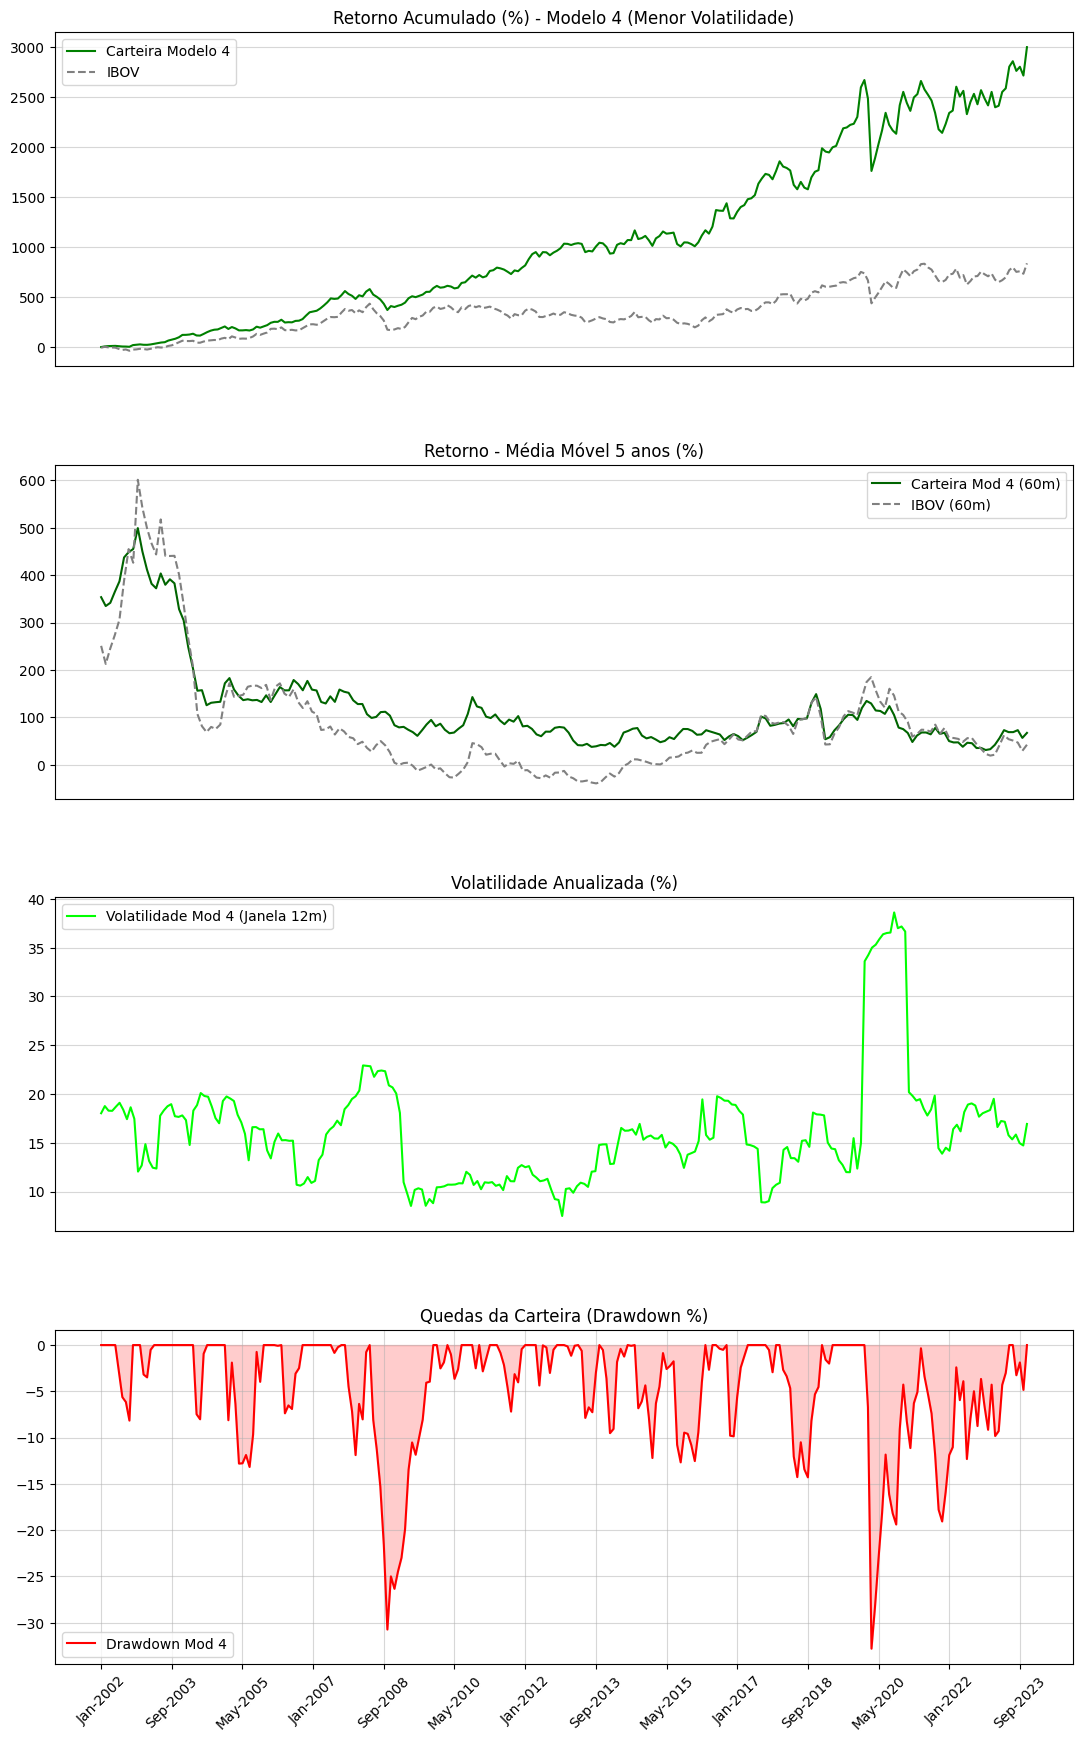

In [ ]:
# ==========================================
# Modelo 4 : Menor Volatilidade
# ==========================================

print("Calculando o Modelo 4 (Foco em Baixa Volatilidade)...\n")

meu_modelo4 = roda_modelo(
    fator1 = 'Volat12',
    fator2 = 'EBIT_DIVLIQ',
    num_acoes=20,
    base_dados=df,
    benchmark=ibov_pct['IBOV'],
    data_ini=data_inicio,
    data_fim=data_final
)

# ------------------------------------------
# PLOT DOS GRÁFICOS DO MODELO 4
# ------------------------------------------

fig, axs = plt.subplots(4, 1, figsize=(12, 18))
fig.tight_layout(pad=5.0)

# 1. Retorno Acumulado
axs[0].plot(meu_modelo4['Ret_acc'] * 100, label='Carteira Modelo 4', color='green')
axs[0].plot(meu_modelo4['Bench_acc'] * 100, label='IBOV', color='gray', linestyle='--')
axs[0].set_title('Retorno Acumulado (%) - Modelo 4 (Menor Volatilidade)')
axs[0].legend()
axs[0].grid(True, alpha=0.5)
axs[0].set_xticks([])

# 2. Janela Movel 60 meses
janela = 60
ret_movel_cart4 = ((1 + meu_modelo4['Ret_acc']) / (1 + meu_modelo4['Ret_acc'].shift(janela)) - 1) * 100
ret_movel_ibov4 = ((1 + meu_modelo4['Bench_acc']) / (1 + meu_modelo4['Bench_acc'].shift(janela)) - 1) * 100

axs[1].plot(ret_movel_cart4.iloc[janela:], label='Carteira Mod 4 (60m)', color='darkgreen')
axs[1].plot(ret_movel_ibov4.iloc[janela:], label='IBOV (60m)', color='gray', linestyle='--')
axs[1].set_title('Retorno - Média Móvel 5 anos (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.5)
axs[1].set_xticks([])

# 3. Volatilidade Anualizada
vol_movel4 = (1 + meu_modelo4['Ret']).rolling(12).std() * np.sqrt(12) * 100
axs[2].plot(vol_movel4, label='Volatilidade Mod 4 (Janela 12m)', color='lime')
axs[2].set_title('Volatilidade Anualizada (%)')
axs[2].legend()
axs[2].grid(True, alpha=0.5)
axs[2].set_xticks([])

# 4. Drawdown
axs[3].plot(meu_modelo4['dd'] * 100, label='Drawdown Mod 4', color='red')
axs[3].fill_between(meu_modelo4.index, meu_modelo4['dd'] * 100, 0, color='red', alpha=0.2)
axs[3].set_title('Quedas da Carteira (Drawdown %)')
axs[3].legend()
axs[3].grid(True, alpha=0.5)
axs[3].tick_params(axis='x', rotation=45)
axs[3].xaxis.set_major_locator(plt.MaxNLocator(15))

plt.show()

Modelo 4: Menor Volatilidade

Fatores Escolhidos: Volat12 + EBIT/Dívida Líquida

Justificativa: Para construir um "bunker" financeiro, cruzamos um filtro puramente estatístico com um filtro de risco de crédito. O Volat12 garante que a ação balança pouco no dia a dia. Já o EBIT/Dívida Líquida alto garante que a empresa gera muito mais caixa do que deve, afastando qualquer risco de falência ou alavancagem excessiva. Em momentos de pânico na bolsa (drawdowns), investidores não vendem empresas com caixa forte, o que segurou a volatilidade deste portfólio no piso estatístico do estudo.

Métricas Obtidas:

Retorno a.a.: 16.96%

Volatilidade a.a.: 16.96%

Relação Retorno/Volatilidade: 1.00

Alpha: 9.23% | Beta: 0.61

Max Drawdown: -32.81%

Conclusão Pessoal sobre os Resultados

O desenvolvimento deste trabalho deixou claro que o mercado financeiro brasileiro (IBOV) apresenta ineficiências latentes que podem ser exploradas através da modelagem quantitativa.

A principal conclusão é a força absurda do fator Momentum no Brasil. Todos os modelos que apresentaram retornos ou Alphas expressivos continham alguma variação de tendência (Mom6 ou Mom12). No entanto, seguir apenas a tendência gera drawdowns violentos. A grande "mágica" (e a originalidade dos testes) esteve em cruzar esse Momentum com fatores de Qualidade (como ROIC) ou métricas de Risco (como Volat12 e níveis de Dívida).

Na prática, percebemos o problema do "cobertor curto" na montagem de portfólios: não existe modelo perfeito. Para buscar o teto de 23.5% de retorno (Modelo 1), tivemos que aceitar quedas severas de quase 42%. Por outro lado, para reduzir o risco ao máximo (Modelo 4), abrimos mão de rentabilidade, caindo para 16.9%.